In [5]:
pip install pyodbc pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:

import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded successfully")

All libraries loaded successfully


In [7]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    r'DRIVER={SQL Server};'
    r'SERVER=DESKTOP-32SBKPS\SQLEXPRESS01;'
    r'DATABASE=TelecomChurn;'
    r'Trusted_Connection=yes;'
)

print("Connected successfully")

Connected successfully


In [ ]:
conn = pyodbc.connect(
    r'DRIVER={SQL Server};'
    r'SERVER=---------------;'        # your server name
    r'DATABASE=TelecomChurn;'
    r'Trusted_Connection=yes;'  # Windows authentication
    
)
print("Connected successfully")


Connected successfully


In [9]:
query = """
SELECT 
    c.ContractType,
    CAST(SUM(f.ChurnFlag) * 100.0 / COUNT(*) AS DECIMAL(5,2)) AS Churn_Rate_Pct
FROM fact_churn f
JOIN dim_contract c ON f.CustomerID = c.CustomerID
GROUP BY c.ContractType
ORDER BY Churn_Rate_Pct DESC
"""

df_contract = pd.read_sql(query, conn)
print(df_contract)

     ContractType  Churn_Rate_Pct
0  Month-to-month           42.71
1        One year           11.27
2        Two year            2.83


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\1063900161.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_contract = pd.read_sql(query, conn)


In [10]:
df_contract

,ContractType,Churn_Rate_Pct
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\4166180933.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


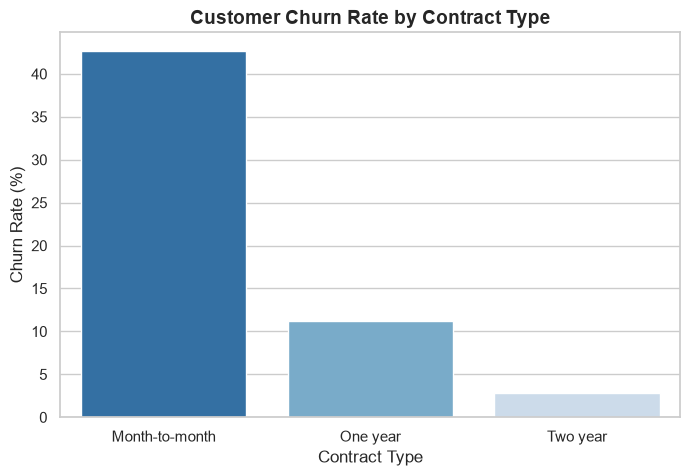

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_contract,
    x="ContractType",
    y="Churn_Rate_Pct",
    palette="Blues_r"  
)
plt.title("Customer Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)

# Display the final chart
plt.show()

In [25]:
query = """
SELECT 
    c.ContractType,
    SUM(CASE WHEN f.ChurnFlag =1 THEN f.MonthlyCharges ELSE 0 End ) AS Revenue_At_Risk
FROM fact_churn f
JOIN dim_contract c ON f.CustomerID = c.CustomerID
GROUP BY c.ContractType
ORDER BY Revenue_At_Risk DESC
"""

df_Revenue_At_Risk = pd.read_sql(Revenue_At_Risk, conn)
print(df_Revenue_At_Risk)

     ContractType  Revenue_at_risk
0        Two year          4165.30
1        One year         14118.45
2  Month-to-month        120847.10


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\2492056205.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_Revenue_At_Risk = pd.read_sql(Revenue_At_Risk, conn)


In [16]:
import pandas as pd

# This query calculates CHURN RATE percentage by contract type
Revenue_At_Risk = """
SELECT 
    c.ContractType,
    SUM(CASE WHEN F.ChurnFlag = 1 THEN f.MonthlyCharges ELSE 0 END) AS Revenue_at_risk
FROM fact_churn f
JOIN dim_contract c ON f.CustomerID = c.CustomerID
GROUP BY c.ContractType
ORDER BY Revenue_at_risk;
"""

df_Revenue_At_Risk = pd.read_sql(query, conn)
print(df_Revenue_At_Risk)

     ContractType  Revenue_At_Risk
0  Month-to-month        120847.10
1        One year         14118.45
2        Two year          4165.30


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\993682219.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_Revenue_At_Risk = pd.read_sql(query, conn)


In [34]:
print(df_Revenue_At_Risk.columns)

Index(['ContractType', 'Revenue_at_risk'], dtype='object')


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\1536293859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


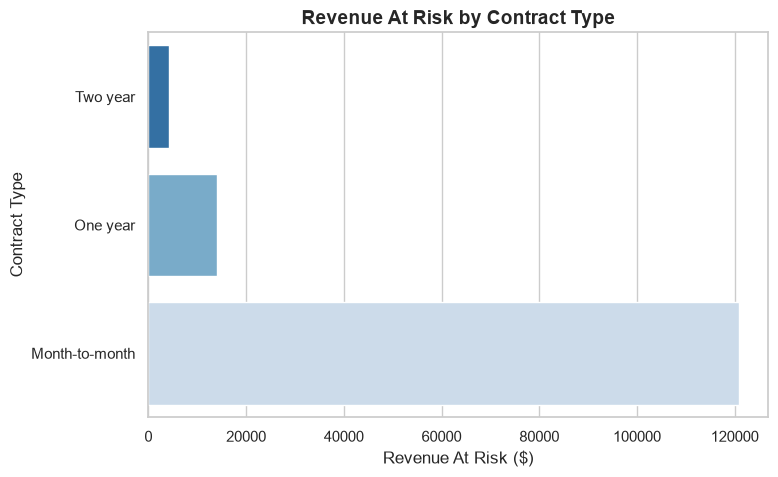

In [35]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_Revenue_At_Risk,
    y="ContractType",
    x="Revenue_at_risk",
    palette="Blues_r"  
)
plt.title("Revenue At Risk by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Revenue At Risk ($)", fontsize=12)
plt.ylabel("Contract Type", fontsize=12)
##plt.ylabel("Contract Type")
##plt.xlabel("Revenue At Risk ($)")

# Display the final chart
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your SQL query using the TenureBuckets CTE you built
query_tenure_cohort = """
WITH TenureBuckets AS (
    SELECT 
        CustomerID,
        ChurnFlag,
        CASE 
            WHEN Tenure <= 12 THEN 'New'
            WHEN Tenure <= 24 THEN 'Developing'
            WHEN Tenure <= 48 THEN 'Established'
            ELSE 'Loyal'
        END AS Tenure_Bucket
    FROM fact_churn
) 
SELECT 
    Tenure_Bucket,
    COUNT(*) AS Total_Customers,
    SUM(ChurnFlag) AS Churned_Customers,
    CAST(SUM(CAST(ChurnFlag AS FLOAT)) * 100.0 / COUNT(*) AS DECIMAL(5,2)) AS Churn_Rate_Pct
FROM TenureBuckets
GROUP BY Tenure_Bucket
ORDER BY Churn_Rate_Pct DESC;
"""

# 2. Pull the data into a pandas DataFrame
df_tenure_cohort = pd.read_sql(query_tenure_cohort, conn)
print("--- Tenure Cohort Data ---")
print(df_tenure_cohort)


--- Tenure Cohort Data ---
  Tenure_Bucket  Total_Customers  Churned_Customers  Churn_Rate_Pct
0           New             2186               1037           47.44
1    Developing             1024                294           28.71
2   Established             1594                325           20.39
3         Loyal             2239                213            9.51


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\1383925613.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tenure_cohort = pd.read_sql(query_tenure_cohort, conn)


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\1161531478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


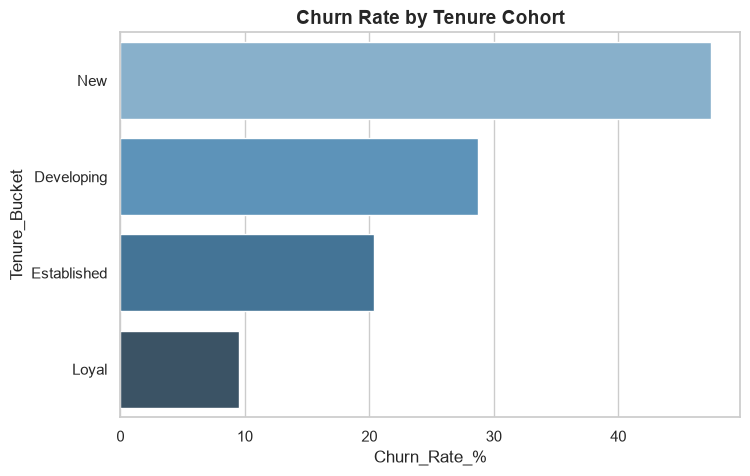

In [19]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_tenure_cohort,
    y="Tenure_Bucket",
    x="Churn_Rate_Pct",
    palette="Blues_d"  
)
plt.title("Churn Rate by Tenure Cohort", fontsize=14, fontweight="bold")
plt.xlabel("Churn_Rate_%", fontsize=12)
plt.ylabel("Tenure_Bucket", fontsize=12)

# Display the final chart
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SQL Query to get churn rate across both Contract Type and Internet Service
query_heatmap = """
SELECT 
    c.ContractType,
    s.InternetService,
    COUNT(f.CustomerID) AS Total_Customers,
    SUM(f.ChurnFlag) AS Churned_Customers,
    CAST(SUM(CAST(f.ChurnFlag AS FLOAT)) * 100.0 / COUNT(f.CustomerID) AS DECIMAL(5,2)) AS Churn_Rate_Pct
FROM fact_churn f
JOIN dim_contract c ON f.CustomerID = c.CustomerID
JOIN dim_services s ON f.CustomerID = s.CustomerID
GROUP BY c.ContractType, s.InternetService;
"""


df_heatmap = pd.read_sql(query_heatmap, conn)
df_pivot = df_heatmap.pivot(index="ContractType", columns="InternetService", values="Churn_Rate_Pct")

print("--- Pivot Table Matrix ---")
print(df_pivot)


--- Pivot Table Matrix ---
InternetService    DSL  Fiber optic     No
ContractType                              
Month-to-month   32.22        54.61  18.89
One year          9.30        19.29   2.47
Two year          1.91         7.23   0.78


C:\Users\Aqib Khan\AppData\Local\Temp\ipykernel_2708\3539977292.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_heatmap = pd.read_sql(query_heatmap, conn)


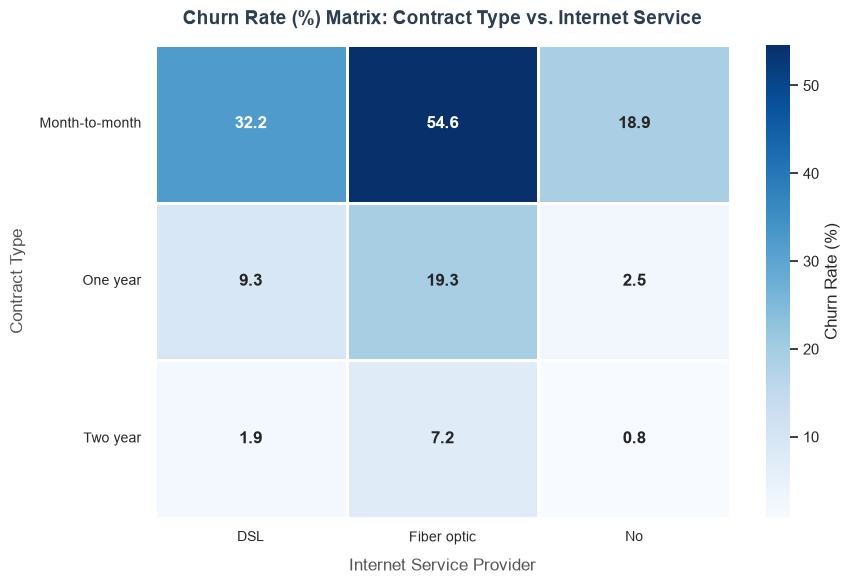

In [21]:

# 3. Build the Heatmap Visualization
plt.figure(figsize=(9, 6))
sns.set_theme(style="white")

# Create heatmap with annotations (showing the exact percentage inside each box)
ax = sns.heatmap(
    df_pivot,
    annot=True,          # Prints the percentage number inside the cell
    fmt=".1f",           # Formats numbers to 1 decimal place
    cmap="Blues",        # Single-hue corporate blue gradient
    cbar_kws={'label': 'Churn Rate (%)'},
    linewidths=1,        # Clean white borders separating the cells
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold"}
)

# 4. Format titles and labels
plt.title("Churn Rate (%) Matrix: Contract Type vs. Internet Service", fontsize=14, fontweight="bold", pad=15, color="#2c3e50")
plt.xlabel("Internet Service Provider", fontsize=12, color="#555555", labelpad=10)
plt.ylabel("Contract Type", fontsize=12, color="#555555", labelpad=10)

# Rotate axis labels for readability
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()